
The `groupby` function or operation (many functions in one) **splits** the DataFrame object into groups, **applies** functions to groups and **combines** the result into a new object. 

In [4]:
import pandas as pd

cardata = {"Mercedes": [2, 4, 0, 4, 0, 3],
           "Ford": [3, 0, 0, 1, 6, 12],
           "Tata": [9, 3, 4, 1, 0, 0],
           "Renault": [12, 1, 0, 0, 3, 1],
          }
carsales = pd.DataFrame(cardata)
carsales.index.rename("SalesPlace", inplace=True)
carsales.rename(index={0: "Salesplace_1",
                       1: "Salesplace_2",
                       2: "Salesplace_3",
                       3: "Salesplace_4",
                       4: "Salesplace_5",
                       5: "Salesplace_6",
                      },
                inplace=True)
carsales.insert(0, "SalesPlaceName",
                ["Europe1", "Australia1", "USA1", "Asia1", "Africa1", "SouthAmerica1"],
                allow_duplicates=True)
newSP1 = pd.DataFrame({"SalesPlaceName": "SouthAmerica1",
                       "Mercedes": 3,
                       "Ford": 2,
                       "Tata": 1,
                       "Renault": 1,},
                      index=["Salesplace_7"])
newSP2 = pd.DataFrame({"SalesPlaceName": "USA1",
                       "Mercedes": 2,
                       "Ford": 15,
                       "Tata": 1,
                       "Renault": 3,},
                      index=["Salesplace_8"])
newSP3 = pd.DataFrame({"SalesPlaceName": "USA1",
                       "Mercedes": 1,
                       "Ford": 11,
                       "Tata": 0,
                       "Renault": 0,},
                      index=["Salesplace_9"])
carsales = pd.concat([carsales, newSP1, newSP2, newSP3])
carsales

,SalesPlaceName,Mercedes,Ford,Tata,Renault
Salesplace_1,Europe1,2,3,9,12
Salesplace_2,Australia1,4,0,3,1
Salesplace_3,USA1,0,0,4,0
Salesplace_4,Asia1,4,1,1,0
Salesplace_5,Africa1,0,6,0,3
Salesplace_6,SouthAmerica1,3,12,0,1
Salesplace_7,SouthAmerica1,3,2,1,1
Salesplace_8,USA1,2,15,1,3
Salesplace_9,USA1,1,11,0,0


In [6]:
def rate_sales(sold):
    if sold >= 15:
        return "Excellent"
    elif sold >= 5:
        return "Sufficient"
    else:
        return "Insufficient"

# Crosstabulations

The `crosstab` function creates standard cross tabulations - combinations of numerical distributions depending on the data type and form of the input data.<br>
A **crosstabulation** (or cross-tab) is a table that displays the frequency distribution of variables to help analyze the relationship between them. <br> This kind of table is useful for **spotting patterns or anomalies** in categorical data.

**Note!** A single label will have a single value.

In [10]:
fordCrossTab = pd.crosstab(carsales["SalesPlaceName"], carsales["Ford"])
fordCrossTab

Ford,0,1,2,3,6,11,12,15
SalesPlaceName,,,,,,,,
Africa1,0,0,0,0,1,0,0,0
Asia1,0,1,0,0,0,0,0,0
Australia1,1,0,0,0,0,0,0,0
Europe1,0,0,0,1,0,0,0,0
SouthAmerica1,0,0,1,0,0,0,1,0
USA1,1,0,0,0,0,1,0,1


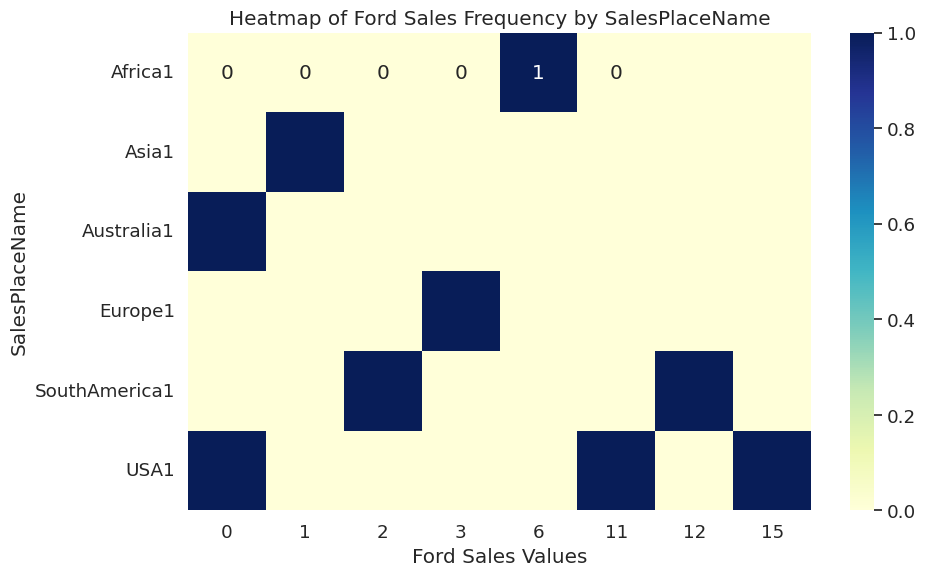

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

fordCrossTab = fordCrossTab.astype(int)
#sns.set(font_scale=1.2)
plt.figure(figsize=(10, 6))
sns.heatmap(fordCrossTab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Heatmap of Ford Sales Frequency by SalesPlaceName")
plt.ylabel("SalesPlaceName")
plt.xlabel("Ford Sales Values")
plt.tight_layout()
plt.show()

***
- crosstabulation for values vs. values<br>
each hit marks the presence of a salesplace with the pair of values for the selected brands

In [21]:
pd.crosstab(carsales["Mercedes"], carsales["Ford"])

Ford,0,1,2,3,6,11,12,15
Mercedes,,,,,,,,
0,1,0,0,0,1,0,0,0
1,0,0,0,0,0,1,0,0
2,0,0,0,1,0,0,0,1
3,0,0,1,0,0,0,1,0
4,1,1,0,0,0,0,0,0


***
- crosstab can show the **frequency distribution** for selected combination of values

In [22]:
pd.crosstab(carsales["Mercedes"], carsales["Ford"], normalize=True)

Ford,0,1,2,3,6,11,12,15
Mercedes,,,,,,,,
0,0.111111,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000,0.111111
3,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000,0.111111,0.000000
4,0.111111,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


***
- crosstab can show frequency distribution calculated for columns

In [23]:
pd.crosstab(carsales["Mercedes"], carsales["Ford"], normalize="columns") 

Ford,0,1,2,3,6,11,12,15
Mercedes,,,,,,,,
0,0.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0


# Groupby

- Useful for creating data descriptions

In [25]:
carsales.groupby(["SalesPlaceName"]).mean()

,Mercedes,Ford,Tata,Renault
SalesPlaceName,,,,
Africa1,0.0,6.000000,0.000000,3.0
Asia1,4.0,1.000000,1.000000,0.0
Australia1,4.0,0.000000,3.000000,1.0
Europe1,2.0,3.000000,9.000000,12.0
SouthAmerica1,3.0,7.000000,0.500000,1.0
USA1,1.0,8.666667,1.666667,1.0


For locations with multiple salesplaces, we get the mean calculated for each location.<br>
For locations with only one salesplace, the mean is the actual sales value.
***

In [26]:
carsales.groupby(["SalesPlaceName"]).sum()

,Mercedes,Ford,Tata,Renault
SalesPlaceName,,,,
Africa1,0,6,0,3
Asia1,4,1,1,0
Australia1,4,0,3,1
Europe1,2,3,9,12
SouthAmerica1,6,14,1,2
USA1,3,26,5,3


***

In [29]:
carsales.groupby("SalesPlaceName", group_keys=True).apply(lambda x: x)

SalesPlaceName  Mercedes  Ford  Tata  Renault
SalesPlaceName                                                           
Africa1        Salesplace_5        Africa1         0     6     0        3
Asia1          Salesplace_4          Asia1         4     1     1        0
Australia1     Salesplace_2     Australia1         4     0     3        1
Europe1        Salesplace_1        Europe1         2     3     9       12
SouthAmerica1  Salesplace_6  SouthAmerica1         3    12     0        1
               Salesplace_7  SouthAmerica1         3     2     1        1
USA1           Salesplace_3           USA1         0     0     4        0
               Salesplace_8           USA1         2    15     1        3
               Salesplace_9           USA1         1    11     0        0

`.apply()` here is working at the **group level**, not the cell or column level.

***

# More examples

## Create a salesrating column with labels

In [32]:
carsales.columns

Index(['SalesPlaceName', 'Mercedes', 'Ford', 'Tata', 'Renault'], dtype='object')

In [35]:
carsales["TotalSales"] = carsales[['Mercedes', 'Ford', 'Tata', 'Renault']].sum(axis=1)
carsales

,SalesPlaceName,Mercedes,Ford,Tata,Renault,TotalSales
Salesplace_1,Europe1,2,3,9,12,26
Salesplace_2,Australia1,4,0,3,1,8
Salesplace_3,USA1,0,0,4,0,4
Salesplace_4,Asia1,4,1,1,0,6
Salesplace_5,Africa1,0,6,0,3,9
Salesplace_6,SouthAmerica1,3,12,0,1,16
Salesplace_7,SouthAmerica1,3,2,1,1,7
Salesplace_8,USA1,2,15,1,3,21
Salesplace_9,USA1,1,11,0,0,12


In [37]:
carsales["SalesRating"] = carsales["TotalSales"].apply(rate_sales)
carsales

,SalesPlaceName,Mercedes,Ford,Tata,Renault,TotalSales,SalesRating
Salesplace_1,Europe1,2,3,9,12,26,Excellent
Salesplace_2,Australia1,4,0,3,1,8,Sufficient
Salesplace_3,USA1,0,0,4,0,4,Insufficient
Salesplace_4,Asia1,4,1,1,0,6,Sufficient
Salesplace_5,Africa1,0,6,0,3,9,Sufficient
Salesplace_6,SouthAmerica1,3,12,0,1,16,Excellent
Salesplace_7,SouthAmerica1,3,2,1,1,7,Sufficient
Salesplace_8,USA1,2,15,1,3,21,Excellent
Salesplace_9,USA1,1,11,0,0,12,Sufficient


***

## Sales Rating cross-tab

In [39]:
pd.crosstab(carsales["SalesPlaceName"], carsales["SalesRating"])

SalesRating,Excellent,Insufficient,Sufficient
SalesPlaceName,,,
Africa1,0,0,1
Asia1,0,0,1
Australia1,0,0,1
Europe1,1,0,0
SouthAmerica1,1,0,1
USA1,1,1,1


## Sales Rating groupby

In [40]:
carsales.groupby("SalesRating", group_keys=True).apply(lambda x: x)

SalesPlaceName  Mercedes  Ford  Tata  Renault  \
SalesRating                                                               
Excellent    Salesplace_1        Europe1         2     3     9       12   
             Salesplace_6  SouthAmerica1         3    12     0        1   
             Salesplace_8           USA1         2    15     1        3   
Insufficient Salesplace_3           USA1         0     0     4        0   
Sufficient   Salesplace_2     Australia1         4     0     3        1   
             Salesplace_4          Asia1         4     1     1        0   
             Salesplace_5        Africa1         0     6     0        3   
             Salesplace_7  SouthAmerica1         3     2     1        1   
             Salesplace_9           USA1         1    11     0        0   

                           TotalSales   SalesRating  
SalesRating                                          
Excellent    Salesplace_1          26     Excellent  
             Salesplace_6          16     Excellent  
             Salesplace_8          21     Excellent  
Insufficient Salesplace_3           4  Insufficient  
Sufficient   Salesplace_2           8    Sufficient  
             Salesplace_4           6    Sufficient  
             Salesplace_5           9    Sufficient  
             Salesplace_7           7    Sufficient  
             Salesplace_9          12    Sufficient